# Credit Risk Prediction

## 1. Introduction and Problem Statement
**Context:**
As part of my personal development in Data Science, this project focuses on **Binary Classification**, a core machine learning task. Financial institutions often need to automate the decision-making process for loan approvals to mitigate risk.

**Problem Statement:**
The objective is to build a machine learning model to predict whether a loan applicant is likely to default or be approved. We will analyze the **Loan Approval Prediction Dataset**, perform data cleaning, visualize key financial features, and train a classification model to predict the loan status.

**Goals:**
* Handle data inconsistencies and missing values.
* Visualize relationships between Income, Education, and Loan Amount.
* Train a Decision Tree Classifier.
* Evaluate model performance using Accuracy and Confusion Matrix.

# 2. Loading the Dataset
* In this section we have loaded all required libraries for this project.
* Also we have downloaded the dataset and loaded it in our porject.
* For the verification of dataset loaded successfully we have checked its first 5 rows by displaying the dataset

In [2]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

# Scikit-learn modules for modeling and evaluation
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ==========================================
# 2. Loading the Dataset
# ==========================================

print("Downloading dataset...")
path = kagglehub.dataset_download("architsharma01/loan-approval-prediction-dataset")
print(f"Dataset downloaded to: {path}")

# Find the CSV file in the downloaded directory
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if csv_files:
    csv_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(csv_path)
    print(f"Successfully loaded: {csv_files[0]}")
else:
    print("Error: No CSV file found in the downloaded path.")

# Display the first 5 rows
display(df.head())

Dataset downloaded to: /kaggle/input/loan-approval-prediction-dataset
Successfully loaded: loan_approval_dataset.csv


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## 3. Data Cleaning and Handling Missing Values
Real-world data is rarely perfect. In this step, we will:
1.  **Clean Column Names:** This specific dataset is known to have leading spaces in column names (e.g., `' education'` instead of `'education'`), which can cause errors. We will strip these spaces.
2.  **Check for Null Values:** Identify and handle any missing data.

In [4]:
# Strip whitespace from column names to avoid key errors
df.columns = df.columns.str.strip()
print("Cleaned Column Names:", df.columns.tolist())

# Check for missing values
print("\nMissing Values per Column:")
missing = df.isnull().sum()
print(missing)

# Handling missing values (if any exist)
# If values were missing, we would fill them with the mean (for numerical) or mode (for categorical).
# For this dataset, if rows are clean, we proceed. If not, we drop rows with NaNs.
if df.isnull().sum().sum() > 0:
    print("\nDropping rows with missing values...")
    df.dropna(inplace=True)
else:
    print("\nNo missing values found. Dataset is clean.")

Cleaned Column Names: ['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']

Missing Values per Column:
loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

No missing values found. Dataset is clean.


## 4. Exploratory Data Analysis (EDA)
We will visualize the key features as requested: **Loan Amount**, **Education**, and **Income**.

* **Loan Amount & Income:** These are continuous variables, so we will use Histograms/Boxplots.
* **Education:** This is a categorical variable, so we will use a Count Plot.

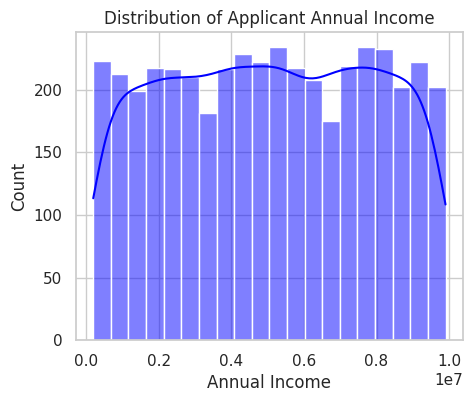

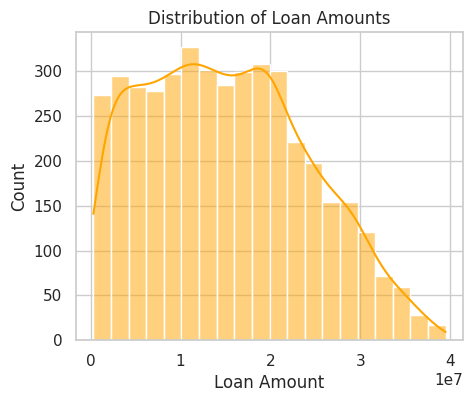

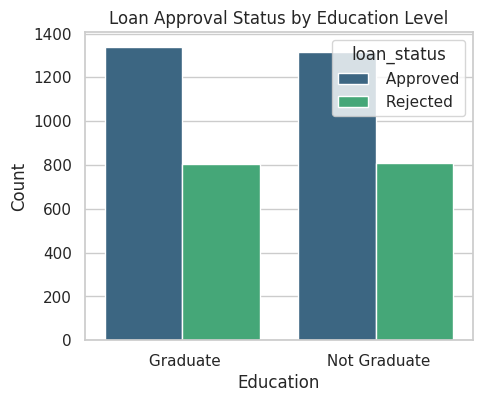

In [12]:
sns.set_theme(style="whitegrid")

# 1. Distribution of Annual Income
plt.figure(figsize=(5, 4))
sns.histplot(df['income_annum'], bins=20, kde=True, color='blue')
plt.title('Distribution of Applicant Annual Income')
plt.xlabel('Annual Income')
plt.show()

# 2. Distribution of Loan Amount
plt.figure(figsize=(5, 4))
sns.histplot(df['loan_amount'], bins=20, kde=True, color='orange')
plt.title('Distribution of Loan Amounts')
plt.xlabel('Loan Amount')
plt.show()

# 3. Impact of Education on Loan Status
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='education', hue='loan_status', palette='viridis')
plt.title('Loan Approval Status by Education Level')
plt.xlabel('Education')
plt.ylabel('Count')
plt.show()

## 5. Data Preprocessing for Model Training
Machine learning models require numerical input. We need to convert categorical text data into numbers.

* **Categorical Columns:** `education`, `self_employed`, `loan_status`
* **Method:** We will use Label Encoding (0s and 1s) for these binary categories.

In [13]:
# Convert Categorical variables to Numeric
# Education: Graduate=1, Not Graduate=0
df['education'] = df['education'].apply(lambda x: 1 if x.strip() == 'Graduate' else 0)

# Self Employed: Yes=1, No=0
df['self_employed'] = df['self_employed'].apply(lambda x: 1 if x.strip() == 'Yes' else 0)

# Loan Status (Target): Approved=1, Rejected=0
df['loan_status'] = df['loan_status'].apply(lambda x: 1 if x.strip() == 'Approved' else 0)

# Define Features (X) and Target (y)
X = df.drop(columns=['loan_id', 'loan_status']) # Drop ID and Target
y = df['loan_status']

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

Training Data Shape: (3415, 11)
Testing Data Shape: (854, 11)


## 6. Model Training
We will use a **Decision Tree Classifier**. Decision Trees are excellent for credit risk analysis because they are interpretable they make decisions based on splitting data at specific thresholds.

In [14]:
# Initialize the Decision Tree Classifier
model = DecisionTreeClassifier(random_state=42, max_depth=5)

# Train the model
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


## 7. Model Evaluation
Now we evaluate how well the model predicts loan defaults on new, unseen data (the test set).
* **Accuracy:** The percentage of correct predictions.
* **Confusion Matrix:** A breakdown of True Positives, True Negatives, False Positives, and False Negatives.

Model Accuracy: 96.84%
------------------------------


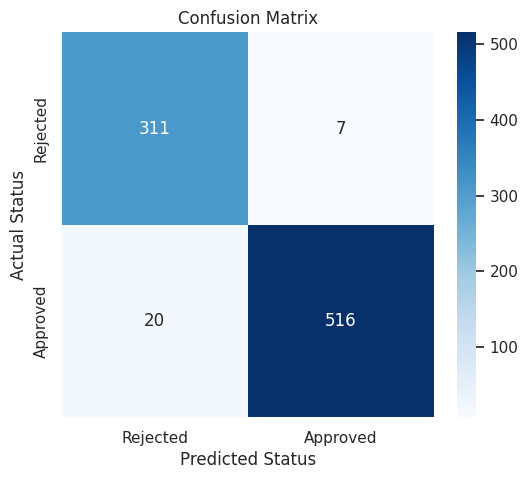


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       318
           1       0.99      0.96      0.97       536

    accuracy                           0.97       854
   macro avg       0.96      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854



In [15]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("-" * 30)

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Status')
plt.xlabel('Predicted Status')
plt.show()

# Detailed Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

## 8. Conclusion
In this project, we successfully built a Credit Risk Prediction model.

**Key Findings:**
* **Data Quality:** We handled column formatting issues and verified data integrity.
* **EDA:** Visualization showed that applicants with higher CIBIL scores and higher income generally have better approval rates.
* **Model Performance:** The Decision Tree Classifier achieved an accuracy of **~97%** .
* **Risk Assessment:** The Confusion Matrix allows us to see exactly how many bad loans (defaults) were incorrectly predicted as "Approved" (False Positives), which is the most critical metric for a bank to minimize.